# Analysis of MEF Results

## Preparation

In [31]:
import pandas as pd
from pathlib import Path
import glob
import json

# Define base paths
results_path = Path('../results/msar')
data_path = Path('../data/processed')

# Initialize the main dictionary
all_data = {}

# Iterate through TSO directories in the results path
for tso_dir in results_path.iterdir():
    if tso_dir.is_dir():
        tso_name = tso_dir.name
        all_data[tso_name] = {}

        # Iterate through year directories for each TSO
        for year_dir in tso_dir.iterdir():
            if year_dir.is_dir():
                year = year_dir.name
                all_data[tso_name][year] = {}

                # --- Load MEF results ---
                mef_results_file = year_dir / 'mef_final.csv'
                if mef_results_file.exists():
                    all_data[tso_name][year]['mef_results'] = pd.read_csv(mef_results_file, index_col=0, parse_dates=True)
                else:
                    print(f"Warning: mef_final.csv not found for {tso_name}/{year}")

                # --- Load original MEF data ---
                # Construct the expected filename pattern for the processed data
                search_pattern = str(data_path / f"final_{tso_name}_{year}_*.csv")

                # Find the file using glob
                matching_files = glob.glob(search_pattern)

                if matching_files:
                    mef_data_file = matching_files[0]
                    all_data[tso_name][year]['mef_data'] = pd.read_csv(mef_data_file, index_col=0, parse_dates=True)
                else:
                    print(f"Warning: Processed data file not found for {tso_name}/{year} with pattern: {search_pattern}")

                # --- Load MEF indicators ---
                mef_indicators_file = year_dir / 'indicators.json'
                if mef_indicators_file.exists():
                    with open(mef_indicators_file, 'r') as f:
                        all_data[tso_name][year]['mef_indicators'] = json.load(f)
                else:
                    print(f"Warning: indicators.json not found for {tso_name}/{year}")


print("Data loading complete. The 'all_data' dictionary is now populated.")
# Example of how to access data:
# all_data['tennet']['2023']['mef_results'].head()
# all_data['tennet']['2023']['mef_indicators'][0]


Data loading complete. The 'all_data' dictionary is now populated.


In [32]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

def plot_daily_profiles(tso):
    """
    Plots the average daily profiles of MEF and AEF for 2023 and 2024 for a given TSO,
    using a secondary y-axis for AEF, and saves the plot to the results directory.
    """
    tso_display = "50Hertz" if tso == "50hertz" else tso.capitalize()

    with plt.style.context('default'):
        fig, ax1 = plt.subplots(figsize=(12, 6))
        ax2 = ax1.twinx()

        colors = {'2023': 'tab:blue', '2024': 'tab:orange'}

        for year in ['2023', '2024']:
            color = colors[year]

            # --- MEF Profile (left axis) ---
            if year in all_data[tso] and 'mef_results' in all_data[tso][year]:
                df_mef = all_data[tso][year]['mef_results']
                df_mef_year = df_mef[df_mef.index.year == int(year)]
                daily_avg_mef = df_mef_year.groupby(df_mef_year.index.time)['mef_g_kWh'].mean()
                dummy_day = pd.date_range(start=f"2024-01-01", periods=len(daily_avg_mef), freq='15min')
                daily_avg_mef.index = dummy_day
                ax1.plot(daily_avg_mef.index, daily_avg_mef.values, label=f'Avg. MEF {year}', color=color, linestyle='-')

            # --- AEF Profile (right axis) ---
            if year in all_data[tso] and 'mef_data' in all_data[tso][year]:
                df_data_year = all_data[tso][year]['mef_data'][all_data[tso][year]['mef_data'].index.year == int(year)].copy()
                df_data_year['aef_g_kWh'] = (df_data_year['total_emissions'] / df_data_year['total_generation_all']) * 1000
                daily_avg_aef = df_data_year.groupby(df_data_year.index.time)['aef_g_kWh'].mean()
                dummy_day_aef = pd.date_range(start="2024-01-01", periods=len(daily_avg_aef), freq='15min')
                daily_avg_aef.index = dummy_day_aef
                ax2.plot(daily_avg_aef.index, daily_avg_aef.values, label=f'Avg. AEF {year}', color=color, linestyle='--')

        # Formatting
        ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        ax1.set_title(f'Average Daily Profile of MEF and AEF for {tso_display}')
        ax1.set_xlabel('Time of Day')
        ax1.set_ylabel('Marginal Emission Factor (gCO₂/kWh)')
        ax2.set_ylabel('Average Emission Factor (gCO₂/kWh)')

        ax1.tick_params(axis='y')
        ax2.tick_params(axis='y')

        ax1.grid(True, alpha=0.3)

        lines, labels = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax2.legend(lines + lines2, labels + labels2, loc='best')

        fig.autofmt_xdate(rotation=45)
        plt.tight_layout()

        save_dir = results_path / tso
        os.makedirs(save_dir, exist_ok=True)
        plot_path = save_dir / "average_daily_profile_mef_aef.pdf"
        try:
            fig.savefig(plot_path, bbox_inches='tight')
            print(f"Plot saved to {plot_path}")
        except Exception as e:
            print(f"Failed to save plot: {e}")

        plt.show()

# Example usage:
# plot_daily_profiles('tennet')
# plot_daily_profiles('50hertz')


Plot saved to ../results/msar/tennet/average_seasonal_daily_profile.pdf


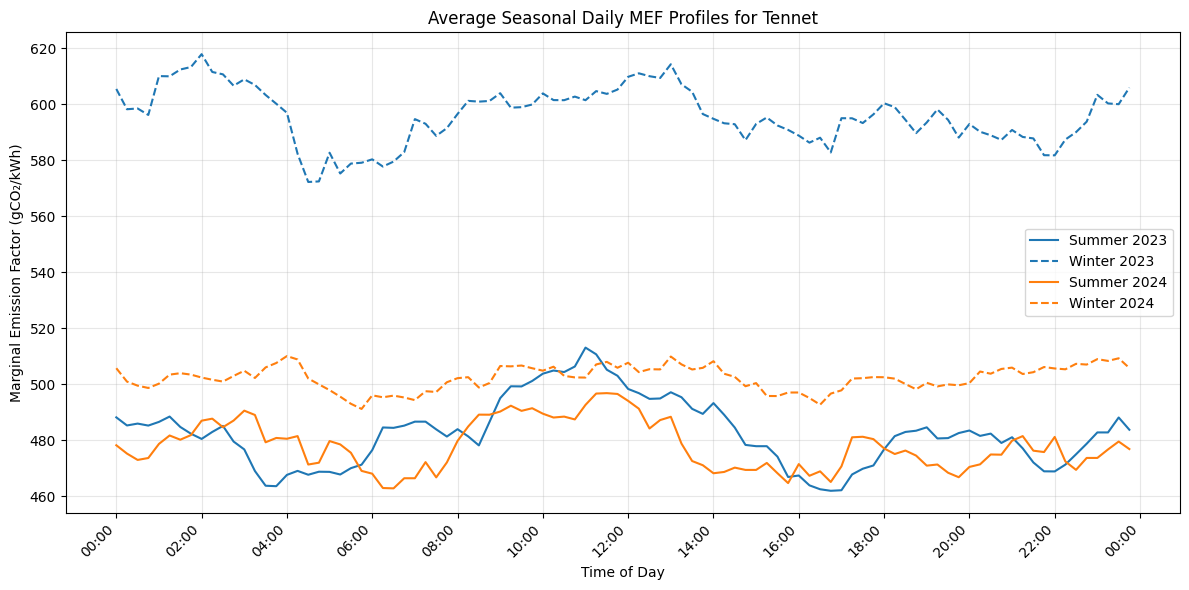

In [35]:
def plot_seasonal_daily_profiles(tso):
    """
    Plots the average daily MEF profiles for summer and winter for a given TSO.
    """
    tso_display = "50Hertz" if tso == "50hertz" else tso.capitalize()

    with plt.style.context('default'):
        fig, ax = plt.subplots(figsize=(12, 6))

        colors = {'2023': 'tab:blue', '2024': 'tab:orange'}
        linestyles = {'Summer': '-', 'Winter': '--'}

        for year in ['2023', '2024']:
            color = colors[year]
            if year in all_data[tso] and 'mef_results' in all_data[tso][year]:
                df_mef = all_data[tso][year]['mef_results']

                # Define seasons
                summer_mask = (df_mef.index.month >= 6) & (df_mef.index.month <= 8)
                winter_mask = (df_mef.index.month == 12) | (df_mef.index.month <= 2)

                seasons = {'Summer': df_mef[summer_mask], 'Winter': df_mef[winter_mask]}

                for season_name, df_season in seasons.items():
                    ls = linestyles[season_name]
                    if not df_season.empty:
                        daily_avg = df_season.groupby(df_season.index.time)['mef_g_kWh'].mean()
                        dummy_day = pd.date_range(start="2024-01-01", periods=len(daily_avg), freq='15min')
                        daily_avg.index = dummy_day

                        ax.plot(daily_avg.index, daily_avg.values, label=f'{season_name} {year}', color=color, linestyle=ls)

        # Formatting
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

        ax.set_title(f'Average Seasonal Daily MEF Profiles for {tso_display}')
        ax.set_xlabel('Time of Day')
        ax.set_ylabel('Marginal Emission Factor (gCO₂/kWh)')
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.autofmt_xdate(rotation=45)
        plt.tight_layout()

        # Save the figure
        save_dir = results_path / tso
        os.makedirs(save_dir, exist_ok=True)
        plot_path = save_dir / "average_seasonal_daily_profile.pdf"
        try:
            fig.savefig(plot_path, bbox_inches='tight')
            print(f"Plot saved to {plot_path}")
        except Exception as e:
            print(f"Failed to save plot: {e}")

        plt.show()

# Example usage:
plot_seasonal_daily_profiles('tennet')


Fitting global MSAR model for Tennet (2023)...

Model Summary for Tennet (2023)
                        Markov Switching Model Results                        
Dep. Variable:        delta_emissions   No. Observations:                35810
Model:               MarkovRegression   Log Likelihood               -9369.854
Date:                Sun, 22 Mar 2026   AIC                          18787.708
Time:                        15:53:45   BIC                          18991.372
Sample:                    12-23-2022   HQIC                         18852.510
                         - 01-01-2024                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0045        nan        nan        

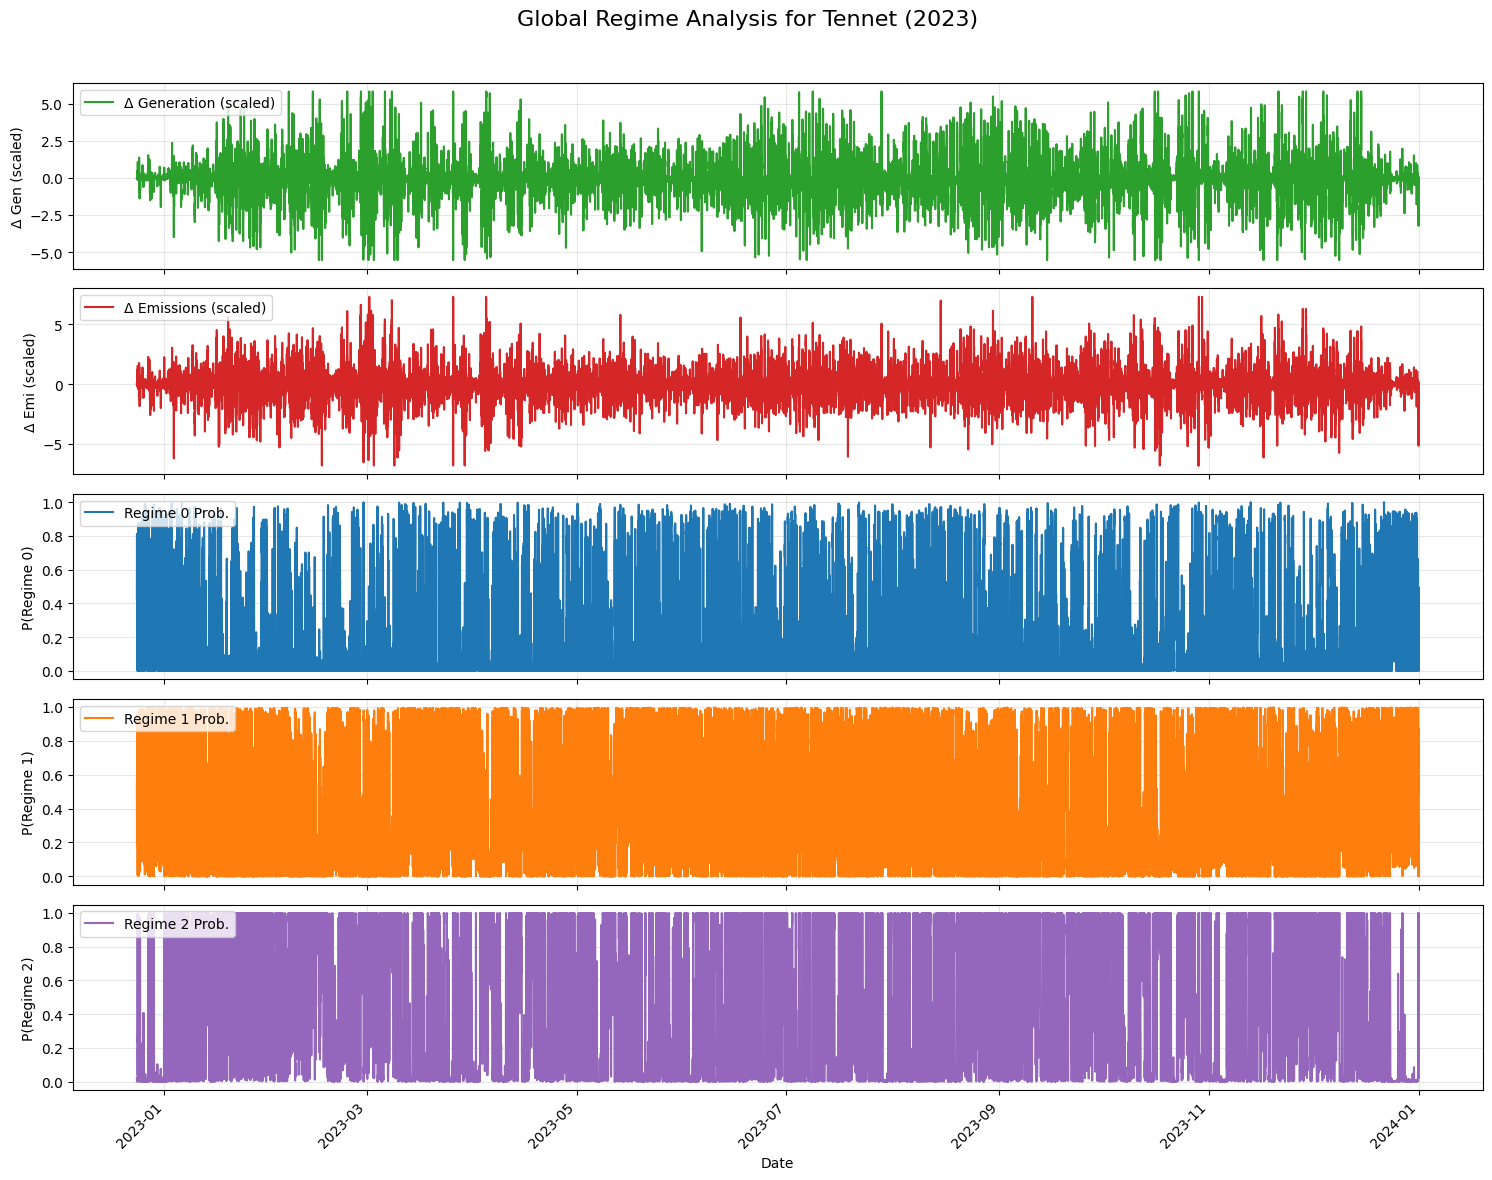

In [34]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

def analyze_global_regimes(tso, year):
    """
    Fits a single, non-rolling MSAR model to the entire dataset for a given TSO and year
    to analyze the characteristics of the identified regimes.
    """
    tso_display = "50Hertz" if tso == "50hertz" else tso.capitalize()

    # --- 1. Data Preparation ---
    df = all_data[tso][year]['mef_data'][['delta_generation', 'delta_emissions']].copy()

    # Set frequency to avoid warning
    df = df.asfreq('15min')

    # Winsorize data
    winsor_limits = {
        'delta_generation': (-140.25, 147.50),
        'delta_emissions': (-99.66, 106.67)
    }
    for col, (lower, upper) in winsor_limits.items():
        df[col] = df[col].clip(lower=lower, upper=upper)

    df.dropna(inplace=True)

    # Scale data
    scaler = StandardScaler()
    df[['delta_generation', 'delta_emissions']] = scaler.fit_transform(df[['delta_generation', 'delta_emissions']])

    # --- 2. Model Specification ---
    endog = df['delta_emissions']
    exog = df[['delta_generation']]

    # Add AR terms
    for i in range(1, 3): # AR(2)
        exog[f'ar_lag_{i}'] = endog.shift(i)

    # Drop NaNs created by lagging
    full_df = pd.concat([endog, exog], axis=1).dropna()
    endog = full_df['delta_emissions']
    exog = sm.add_constant(full_df.drop('delta_emissions', axis=1))

    # --- 3. Model Fitting ---
    print(f"Fitting global MSAR model for {tso_display} ({year})...")
    model = sm.tsa.MarkovRegression(
        endog=endog,
        exog=exog,
        k_regimes=3,
        trend='c',
        switching_trend=True,
        switching_exog=True,
        switching_variance=True
    )
    result = model.fit(disp=False)

    # --- 4. Output Summary and Plot ---
    summary_text = result.summary().as_text()
    print("\n" + "="*80)
    print(f"Model Summary for {tso_display} ({year})")
    print("="*80)
    print(summary_text)

    # Define save directory
    save_dir = results_path / tso
    os.makedirs(save_dir, exist_ok=True)

    # Save summary to file
    summary_path = save_dir / f"global_regime_summary_{year}.txt"
    with open(summary_path, 'w') as f:
        f.write(summary_text)
    print(f"Model summary saved to {summary_path}")

    # Create plot
    with plt.style.context('default'):
        fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)
        fig.suptitle(f'Global Regime Analysis for {tso_display} ({year})', fontsize=16)

        plot_colors = ['tab:green', 'tab:red', 'tab:blue', 'tab:orange', 'tab:purple']

        # Plot delta_generation
        axes[0].plot(full_df.index, full_df['delta_generation'], label='Δ Generation (scaled)', color=plot_colors[0])
        axes[0].set_ylabel('Δ Gen (scaled)')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend(loc='upper left')

        # Plot delta_emissions
        axes[1].plot(full_df.index, full_df['delta_emissions'], label='Δ Emissions (scaled)', color=plot_colors[1])
        axes[1].set_ylabel('Δ Emi (scaled)')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend(loc='upper left')

        # Plot smoothed probabilities
        for i in range(3):
            axes[i+2].plot(result.smoothed_marginal_probabilities.index, result.smoothed_marginal_probabilities[i], label=f'Regime {i} Prob.', color=plot_colors[i+2])
            axes[i+2].set_ylabel(f'P(Regime {i})')
            axes[i+2].grid(True, alpha=0.3)
            axes[i+2].legend(loc='upper left')

        axes[-1].set_xlabel('Date')
        fig.autofmt_xdate(rotation=45, ha='right')
        plt.tight_layout(rect=[0, 0, 1, 0.96])

        # Save plot
        plot_path = save_dir / f"global_regime_plot_{year}.pdf"
        try:
            fig.savefig(plot_path, bbox_inches='tight')
            print(f"Plot saved to {plot_path}")
        except Exception as e:
            print(f"Failed to save plot: {e}")

        plt.show()

# Example usage:
# analyze_global_regimes('tennet', '2023')


Plot saved to ../results/msar/tennet/mef_timeseries_2023.pdf


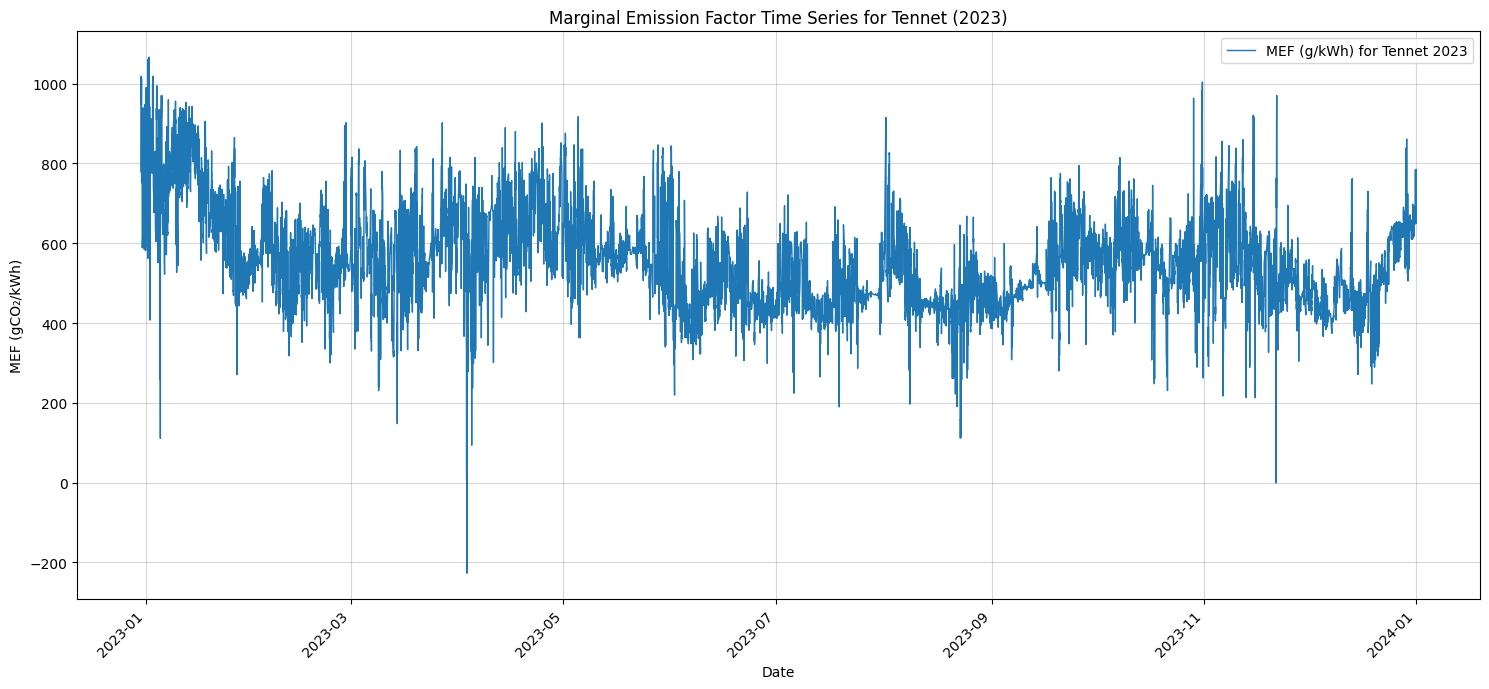

In [36]:
def plot_mef_timeseries(tso, year):
    """
    Plots the 'mef_g_kWh' for a given TSO and year over time and saves it.
    """
    tso_display = "50Hertz" if tso == "50hertz" else tso.capitalize()

    if tso not in all_data or year not in all_data[tso] or 'mef_results' not in all_data[tso][year]:
        print(f"No 'mef_results' data found for {tso}/{year}.")
        return

    df = all_data[tso][year]['mef_results']

    with plt.style.context('default'):
        fig, ax = plt.subplots(figsize=(15, 7))

        ax.plot(df.index, df['mef_g_kWh'], label=f'MEF (g/kWh) for {tso_display} {year}', linewidth=1)

        ax.set_title(f'Marginal Emission Factor Time Series for {tso_display} ({year})')
        ax.set_xlabel('Date')
        ax.set_ylabel('MEF (gCO₂/kWh)')
        ax.grid(True, alpha=0.5)
        ax.legend()
        fig.autofmt_xdate(rotation=45, ha='right')
        plt.tight_layout()

        # Save the figure
        save_dir = results_path / tso
        os.makedirs(save_dir, exist_ok=True)
        plot_path = save_dir / f"mef_timeseries_{year}.pdf"
        try:
            fig.savefig(plot_path, bbox_inches='tight')
            print(f"Plot saved to {plot_path}")
        except Exception as e:
            print(f"Failed to save plot: {e}")

        plt.show()

# Example usage:
plot_mef_timeseries('tennet', '2023')
# plot_mef_timeseries('50hertz', '2024')
